**Physics-Informed Neural Network (PINN) for a Harmonic Oscillator**

This notebook implements a PINN to solve the equation for a damped harmonic oscillator. This is a classic application for a PINN. Instead of just learning from data, the network will use the underlying differential equation as its loss function.

For a damped harmonic oscillator, the governing equation is: 
$$m\frac{d^2u}{dt^2}+\mu \frac{du}{dt} + ku = 0$$

where $m$ is the mass of the object, $\mu$ is the damping coefficient - the resistive force proportional to velocity and $k$ is the spring constant - stiffness of the restoring force.

We will constrain the neural network using the physics residual:
$$f=\frac{d^2u}{dt^2} + 2\zeta \omega_0 \frac{du}{dt} + \omega_0 ^2 u$$

where $u$ is the displacement, $t$ is time, $f$ is the physics residual, $\omega_0$ is the undamped natural frequency and $\zeta$ is the damping ratio.

To be more specific given a time $t$ the network predicts $u(t)$ which is the time-dependendt displacement of the oscillator from its equilibrium position and in the context of our PINN it is the output of the NN. The physics residual $f$ is the residual function of the ordinary differential equation. In the context of this PINN - according to physics, the sum of the forces (mass, damping, and spring) should equal zero (see the first equation). Therefore, $f$ should ideally be $0$ everywhere. The PINN works by calculating: $$f = \frac{d^2u}{dt^2} + 2\zeta\omega_0 \frac{du}{dt} + \omega_0^2 u$$ so basically the "physics loss" is simply trying to minimize $f^2$ so that the network's predictions actually obey the laws of physics. The undapmped natural frequency $\omega_0$ is the frequency at which the system would oscillate if there were no friction - damping. It is defined as $\omega_0 = \sqrt{k/m}$ and it determines how "stiff" the system is. The damping ratio $\zeta$ 



is a dimensionless measure describing how oscillations in a system decay after a disturbance. If $\zeta < 1$ then the system is underdamped - the system oscillates while the amplitude gradually decreases, if $\zeta = 1$ the system is critically damped - the system returns to equilibrium as quickly as possible without oscillating and if $\zeta > 1$ the system is overdamped - the system returns to equilibrium slowly without oscillating. 


It is defined as the ratio of the actual damping $c$ to the critical damping $c_c$:

$$\zeta = \frac{c}{c_c}$$

Where the critical damping coefficient is $c_c = 2\sqrt{mk}$.

*Summary table for the code implementation:*


| Variables in equation   | Variables in code | Role        |
|--------|-----|-------------|
| $t$  | ```t_physics```  | the input - time points      |
| $u$    | ```u_pred```  | the output - predicted points    |
| $\omega_0^2$  | ```w0**2```  | constant setting the oscillation speed     |
| 2$\zeta\omega$  | ```d```  | the damping coefficient (set to 2 in the code)    |


**Code:**

Here we check the python version being used just to make sure we have a supported version for PyTorch

In [36]:
import sys
print(sys.version)

3.14.3 | packaged by Anaconda, Inc. | (main, Feb 24 2026, 22:45:56) [MSC v.1942 64 bit (AMD64)]


*Imports and Setup*

We begin by importing PyTorch for the neural network and autograd capabilities, and Matplotlib for visualizing the results. We also define the physical constants for our specific system.

In [37]:
# imports and Setup
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# GPU check
# this line doesn't want to switch to CPU...
#device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') 
device = torch.device('cpu')

# physical constants
d, w0 = 2, 20  # d represents 2*zeta*w_0

*Defining the NN architecture*

We use a Fully Connected Network (FCN)
 - Input: Time $t$
 - Output: Displacement $u$
 - Activation: We use tanh because it is infinitely differentiable, which is crucial for calculating the second-order derivatives in our physics loss.

In [38]:
# defining the NN architecture

class FCN(nn.Module):
    "Fully Connected Network for PINN"
    def __init__(self, N_INPUT, N_OUTPUT, N_HIDDEN, N_LAYERS):
        super().__init__()
        activation = nn.Tanh
        self.fcs = nn.Sequential(*[
            nn.Linear(N_INPUT, N_HIDDEN),
            activation()
        ])
        self.fch = nn.Sequential(*[
            nn.Sequential(*[nn.Linear(N_HIDDEN, N_HIDDEN), activation()]) for _ in range(N_LAYERS-1)
        ])
        self.fce = nn.Linear(N_HIDDEN, N_OUTPUT)
        
    def forward(self, x):
        x = self.fcs(x)
        x = self.fch(x)
        x = self.fce(x)
        return x

*The physics loss and training loop*

The total loss function consists of two parts:
- boundary loss $Loss_{BC}$: Ensures the network matches the initial conditions $u(0)=1$
- physics loss $Loss_{Phys}$: Measures how well the network satisfies the ODE: $f = u'' + du' + \omega_0^2 u$. We aim for $f \approx 0$.
We use Automatic Differentiation (Autograd) to compute the derivatives of $u$ with respect to $t$.

In [51]:
# the physics loss and training loop
# oscillator's constants
d, w0 = 2, 20

# training data (initial conditions)
t_boundary = torch.tensor([0.]).view(-1,1).requires_grad_(True)
u_boundary = torch.tensor([1.]).view(-1,1) # Initial displacement

# collocation points (where we enforce the physics)
t_physics = torch.linspace(0, 1, 30).view(-1,1).requires_grad_(True)

# training loop for range and dynamics ---
model = FCN(1, 1, 32, 3).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# weighting: multiplied boundary losses by 500 to overcome the high w0^2 (400) - now it wont find the trivial solution
lambda_ic = 500.0 

for i in range(20001):
    optimizer.zero_grad()
    
    # 1. position initial condition: u(0) = 1
    u_pred_0 = model(t_boundary)
    loss_u0 = torch.mean((u_pred_0 - u_boundary)**2)
    
    # 2. velocity initial condition: u'(0) = 0
    # this part prevents the NN from "jumping" to zero immediately
    u_grad_0 = torch.autograd.grad(u_pred_0, t_boundary, torch.ones_like(u_pred_0), create_graph=True)[0]
    loss_v0 = torch.mean(u_grad_0**2)
    
    # 3. loss from physics (ODE residual)
    u_p = model(t_physics)
    # using autograd to find derivatives
    dt = torch.autograd.grad(u_p, t_physics, torch.ones_like(u_p), create_graph=True)[0]
    dt2 = torch.autograd.grad(dt, t_physics, torch.ones_like(dt), create_graph=True)[0]
    
    # ODE residual: u'' + d*u' + w0^2*u = 0
    physics_residual = dt2 + d*dt + (w0**2)*u_p
    loss_phys = torch.mean(physics_residual**2)
    
    # total loss with weighting
    # we force the model to respect the start at 1.0 in order to not jump to the trivial solution
    loss = lambda_ic * (loss_u0 + loss_v0) + loss_phys
    
    loss.backward()
    optimizer.step()
    
    if i % 1000 == 0:
        print(f"Epoch {i}: Loss {loss.item():.4f} (u0 error: {loss_u0.item():.6f})")

Epoch 0: Loss 14328.0186 (u0 error: 1.759162)
Epoch 1000: Loss 490.7452 (u0 error: 0.965270)
Epoch 2000: Loss 490.5976 (u0 error: 0.962838)
Epoch 3000: Loss 490.4828 (u0 error: 0.962513)
Epoch 4000: Loss 489.9128 (u0 error: 0.960693)
Epoch 5000: Loss 477.5660 (u0 error: 0.927206)
Epoch 6000: Loss 367.8970 (u0 error: 0.545387)
Epoch 7000: Loss 358.7609 (u0 error: 0.525602)
Epoch 8000: Loss 340.1269 (u0 error: 0.489507)
Epoch 9000: Loss 315.7552 (u0 error: 0.425167)
Epoch 10000: Loss 285.5346 (u0 error: 0.347652)
Epoch 11000: Loss 253.0663 (u0 error: 0.297779)
Epoch 12000: Loss 224.3343 (u0 error: 0.222135)
Epoch 13000: Loss 205.4318 (u0 error: 0.187071)
Epoch 14000: Loss 144.6131 (u0 error: 0.124850)
Epoch 15000: Loss 105.6543 (u0 error: 0.063603)
Epoch 16000: Loss 46.0246 (u0 error: 0.034866)
Epoch 17000: Loss 26.3598 (u0 error: 0.016957)
Epoch 18000: Loss 17.1017 (u0 error: 0.008452)
Epoch 19000: Loss 12.9744 (u0 error: 0.004330)
Epoch 20000: Loss 11.7220 (u0 error: 0.003107)


*Visualization of PINN*

Now we evaluate the trained model over the time interval $[0, 1]$ and plot the predicted displacement. This curve represents the "physics-informed" solution to the damping problem.

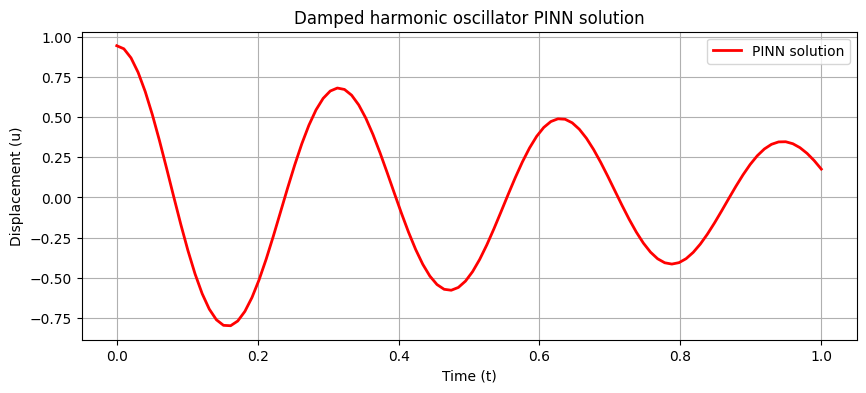

In [52]:
# visualizing the results
# generates test points
t_test = torch.linspace(0, 1, 100).view(-1,1)
u_test = model(t_test).detach()

plt.figure(figsize=(10,4))
plt.plot(t_test.numpy(), u_test.numpy(), label="PINN solution", color='red', linewidth=2)
plt.title("Damped harmonic oscillator PINN solution")
plt.xlabel("Time (t)")
plt.ylabel("Displacement (u)")
plt.legend()
plt.grid(True)
plt.show()

**Conclusions**

In this experiment we used the following parameters: 
- $\omega_0 = 20$
- $d$ (representing $2\zeta\omega_0$) $= 2$

By rearranging the formula $\zeta = \frac{d}{2\omega_0}$, we can calculate the damping ratio enforced by the network:

$$\zeta =\frac{2}{2(20)} = 0.05$$



*Observations:*

 - regime: since $\zeta = 0.05< 1$ the system is in the underdamped regime,
 - behavior: as expected from an underdamped system, the PINN's plot shows a clear oscillatory pattern where the amplitude gradually decays over time,
 - accuracy: the NN successfully "discovered" this oscillatory behavior without being given any training points other than the initial starting position ($t=0, u=1$). It learned the rest of the curve entirely by minimizing the physics residual.

*The Exact Solution*

For an underdamped harmonic oscillator ($\zeta < 1$), the general displacement formula is:

$$u_{exact}(t) = e^{-\zeta\omega_0 t} \left( A \cos(\omega_d t) + B \sin(\omega_d t) \right)$$

In order to find the exact solution for our specific initial conditions ($u(0) = 1$ and $v(0)=0$) we plug the $t=0$ into the general formula :

$$ $1= u(0) = e^0 (A \cdot 1 + B \cdot 0) = A$$
and by taking the derivative of $u(t=0)$ we find that $B = \frac{\zeta \omega_0}{\omega_d}$.

Thus the exact equation is:

$$u_{exact}(t) = e^{-\zeta\omega_0 t} \left( \cos(\omega_d t) + \frac{\zeta\omega_0}{\omega_d} \sin(\omega_d t) \right)$$

where $\omega_d = \omega_0 \sqrt{1-\zeta^2}$.

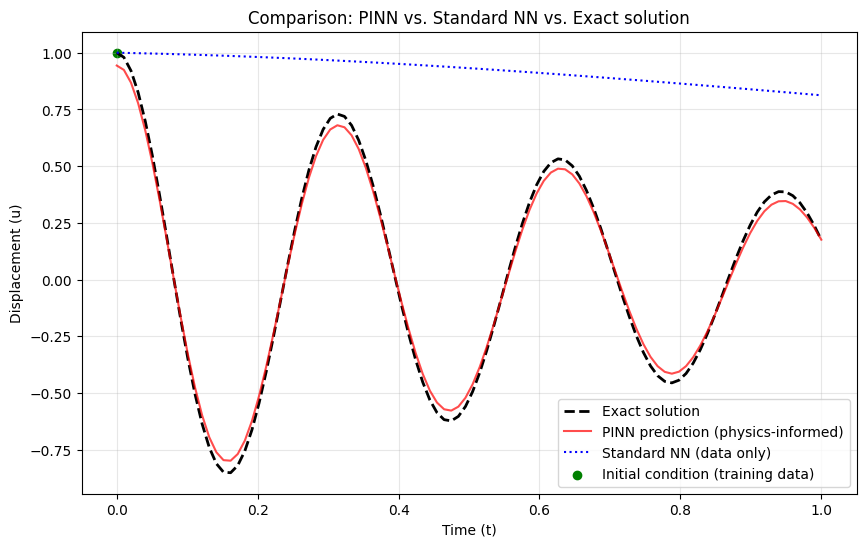

In [54]:
import numpy as np

# 1. exact solution definition
def exact_solution(t, d, w0):
    """
    this part calculates the analytical solution for the underdamped HO.
    d = 2 * zeta * w0
    """
    zeta = d / (2 * w0)
    w_d = w0 * np.sqrt(1 - zeta**2)
    # initial conditions: u(0)=1, u'(0)=0
    u0 = 1.0
    v0 = 0.0
    
    # analytical formula
    exponent = np.exp(-zeta * w0 * t)
    cosine_term = u0 * np.cos(w_d * t)
    sine_term = ((v0 + zeta * w0 * u0) / w_d) * np.sin(w_d * t)
    
    return exponent * (cosine_term + sine_term)

# 2. training a standard NN (loss = MSE only)
# this model will only see the initial data point (t=0, u=1) and will NOT use the physics_residual (loss2)
model_standard = FCN(1, 1, 32, 3).to(device)
optimizer_std = torch.optim.Adam(model_standard.parameters(), lr=1e-3)

for i in range(10001):
    optimizer_std.zero_grad()
    
    # only MSE loss at the boundary
    u_pred_std = model_standard(t_boundary)
    loss_mse = torch.mean((u_pred_std - u_boundary)**2)
    
    loss_mse.backward()
    optimizer_std.step()

# 3. visualisation and comparison
t_plot = np.linspace(0, 1, 100)
u_exact = exact_solution(t_plot, d, w0)

# predictions from both models
t_tensor = torch.linspace(0, 1, 100).view(-1,1).to(device)
u_pinn = model(t_tensor).detach().cpu().numpy()
u_standard = model_standard(t_tensor).detach().cpu().numpy()

plt.figure(figsize=(10, 6))
plt.plot(t_plot, u_exact, label='Exact solution', color='black', linestyle='--', linewidth=2)
plt.plot(t_plot, u_pinn, label='PINN prediction (physics-informed)', color='red', alpha=0.7)
plt.plot(t_plot, u_standard, label='Standard NN (data only)', color='blue', linestyle=':')
plt.scatter([0], [1], color='green', label='Initial condition (training data)')

plt.title('Comparison: PINN vs. Standard NN vs. Exact solution')
plt.xlabel('Time (t)')
plt.ylabel('Displacement (u)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

- *Accuracy check:* By plotting the Exact Solution alongside the PINN prediction we prove that the PINN correctly follows the physics of the system (frequency and decay).
- *The "ordinary" NN failure:* The Standard NN is trained only on the initial point ($t=0, u=1$). Without the physics loss (`loss2`), it has no way of knowing the system should oscillate. In the plot we are able to observe the blue line (Standard NN) stayinh as a flat-ish line, while the red line (PINN) follows the prediction from physics.
- *Utility demonstration:* This visually proves that PINNs are useful because they can predict the behavior of a complex system even when there are almost no training data, as long as we know the underlying physical laws.